Bayesian Time Series Forecasting with PyMC3
============================================

This notebook demonstrates Bayesian forecasting of annual means using PyMC3.
We'll model the data with a linear trend plus noise, then forecast 10 years ahead.

Mathematical Framework:
-----------------------
We model the observed data y_t as:
    y_t = α + β*t + ε_t
    
where:
- α (alpha) is the intercept
- β (beta) is the trend coefficient (slope)
- t is the time index (0, 1, 2, ..., 36)
- ε_t ~ Normal(0, σ²) is the observation noise

Bayesian Approach:
------------------
Instead of point estimates, we specify prior distributions for our parameters:
    α ~ Normal(μ_α, σ_α²)     # Prior belief about intercept
    β ~ Normal(μ_β, σ_β²)     # Prior belief about trend
    σ ~ HalfNormal(σ_prior)   # Prior for noise (positive only)

The posterior distribution P(α,β,σ|data) is computed via MCMC sampling:
    P(α,β,σ|data) ∝ P(data|α,β,σ) × P(α) × P(β) × P(σ)

For forecasting, we generate predictions from the posterior predictive distribution:
    y_future ~ Normal(α + β*t_future, σ²)

In [39]:
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
import arviz as az
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)

# Your observed data (1989-2024)
observations = np.array([134.3, 121.7, 114.1, 135.7, 133.9, 135.7, 146.5, 139.3,
                        133.2, 133.2, 126.0, 111.0, 110.0, 165.0, 154.0, 135.0,
                        154.0, 171.0, 111.1, 138.6, 91.5, 144.1, 140.1,
                        140.3, 125.3, 117.2, 125.3, 133.3, 117.2, 120.0, 105.0,
                        93.0, 106.0, 99.7, 103.3, 101.6])
# Time indices
years = np.arange(1989, 2025)
t = np.arange(len(observations))  # 0 to 36
n_forecast = 10
t_forecast = np.arange(len(observations), len(observations) + n_forecast)
years_forecast = np.arange(2025, 2035)

print(f"Observed data: {len(observations)} years (1989-2024)")
print(f"Forecasting: {n_forecast} years (2025-2034)")
print(f"\nData statistics:")
print(f"  Mean: {np.mean(observations):.2f}")
print(f"  Std: {np.std(observations):.2f}")
print(f"  Min: {np.min(observations):.2f}")
print(f"  Max: {np.max(observations):.2f}")

Observed data: 36 years (1989-2024)
Forecasting: 10 years (2025-2034)

Data statistics:
  Mean: 126.84
  Std: 19.08
  Min: 91.50
  Max: 171.00


In [40]:
# ============================================================================
# MODEL 1: Linear Trend Model
# ============================================================================
print("\n" + "="*70)
print("Building Bayesian Linear Trend Model")
print("="*70)

with pm.Model() as linear_model:
    # Priors
    # We use weakly informative priors based on the data
    alpha = pm.Normal('alpha', mu=130, sigma=50)  # Intercept around mean of data
    beta = pm.Normal('beta', mu=0, sigma=5)        # Trend (allow positive/negative)
    sigma = pm.HalfNormal('sigma', sigma=30)       # Noise standard deviation
    
    # Expected value (deterministic)
    mu = alpha + beta * t
    
    # Likelihood: observed data
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=observations)
    
    # Sample from posterior using NUTS sampler
    print("\nSampling from posterior distribution...")
    trace = pm.sample(2000, tune=1000, return_inferencedata=True, 
                     target_accept=0.95, random_seed=42)

print("\nPosterior Summary:")
print(az.summary(trace, var_names=['alpha', 'beta', 'sigma']))


Building Bayesian Linear Trend Model

Sampling from posterior distribution...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 6 seconds.



Posterior Summary:
          mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha  140.899  5.766  130.087  151.882      0.100    0.078    3346.0   
beta    -0.806  0.285   -1.332   -0.243      0.005    0.004    3383.0   
sigma   18.131  2.263   13.981   22.274      0.036    0.037    4069.0   

       ess_tail  r_hat  
alpha    3891.0    1.0  
beta     3635.0    1.0  
sigma    3756.0    1.0  


In [27]:
# ============================================================================
# GENERATE FORECASTS
# ============================================================================
print("\n" + "="*70)
print("Generating Forecasts with Uncertainty")
print("="*70)

with linear_model:
    # Posterior predictive for historical data (for model checking)
    ppc = pm.sample_posterior_predictive(trace, random_seed=42)
    
    # Forecast future values
    # We need to update the mu for future time points
    mu_forecast = trace.posterior['alpha'].values[np.newaxis, :, :] + trace.posterior['beta'].values[np.newaxis, :, :] * t_forecast.reshape(-1, 1, 1)
    
    # Sample from predictive distribution (adds observation noise)
    # Shape: (n_forecast, n_chains, n_samples)
    forecasts = np.random.normal(
        loc=mu_forecast,
        scale=trace.posterior['sigma'].values,
    )

# Extract forecast statistics
# Flatten chain and sample dimensions
forecasts_flat = forecasts.reshape(n_forecast, -1)
forecast_mean = forecasts_flat.mean(axis=1)
forecast_median = np.median(forecasts_flat, axis=1)
forecast_std = forecasts_flat.std(axis=1)

# Credible intervals
ci_50 = np.percentile(forecasts_flat, [25, 75], axis=1)
ci_90 = np.percentile(forecasts_flat, [5, 95], axis=1)
ci_95 = np.percentile(forecasts_flat, [2.5, 97.5], axis=1)

print("\nForecast Summary:")
print(f"{'Year':<8} {'Mean':<8} {'Median':<8} {'Std':<8} {'95% CI'}")
print("-" * 60)
for i, year in enumerate(years_forecast):
    print(f"{year:<8} {forecast_mean[i]:<8.1f} {forecast_median[i]:<8.1f} "
          f"{forecast_std[i]:<8.1f} [{ci_95[0,i]:.1f}, {ci_95[1,i]:.1f}]")

Sampling: [y_obs]


Output()


Generating Forecasts with Uncertainty



Forecast Summary:
Year     Mean     Median   Std      95% CI
------------------------------------------------------------
2025     111.9    111.8    19.1     [73.5, 149.6]
2026     111.3    111.3    19.1     [73.7, 148.7]
2027     110.4    110.2    19.2     [73.5, 148.3]
2028     109.5    109.6    19.2     [71.9, 146.8]
2029     108.6    108.8    19.4     [70.3, 146.5]
2030     108.1    108.2    19.4     [69.1, 145.9]
2031     107.4    107.4    19.7     [68.1, 146.3]
2032     106.7    106.8    19.8     [67.7, 145.9]
2033     105.7    105.7    19.5     [66.8, 144.6]
2034     105.1    104.9    20.0     [66.4, 144.8]



Creating Visualizations


KeyError: 'y_obs'

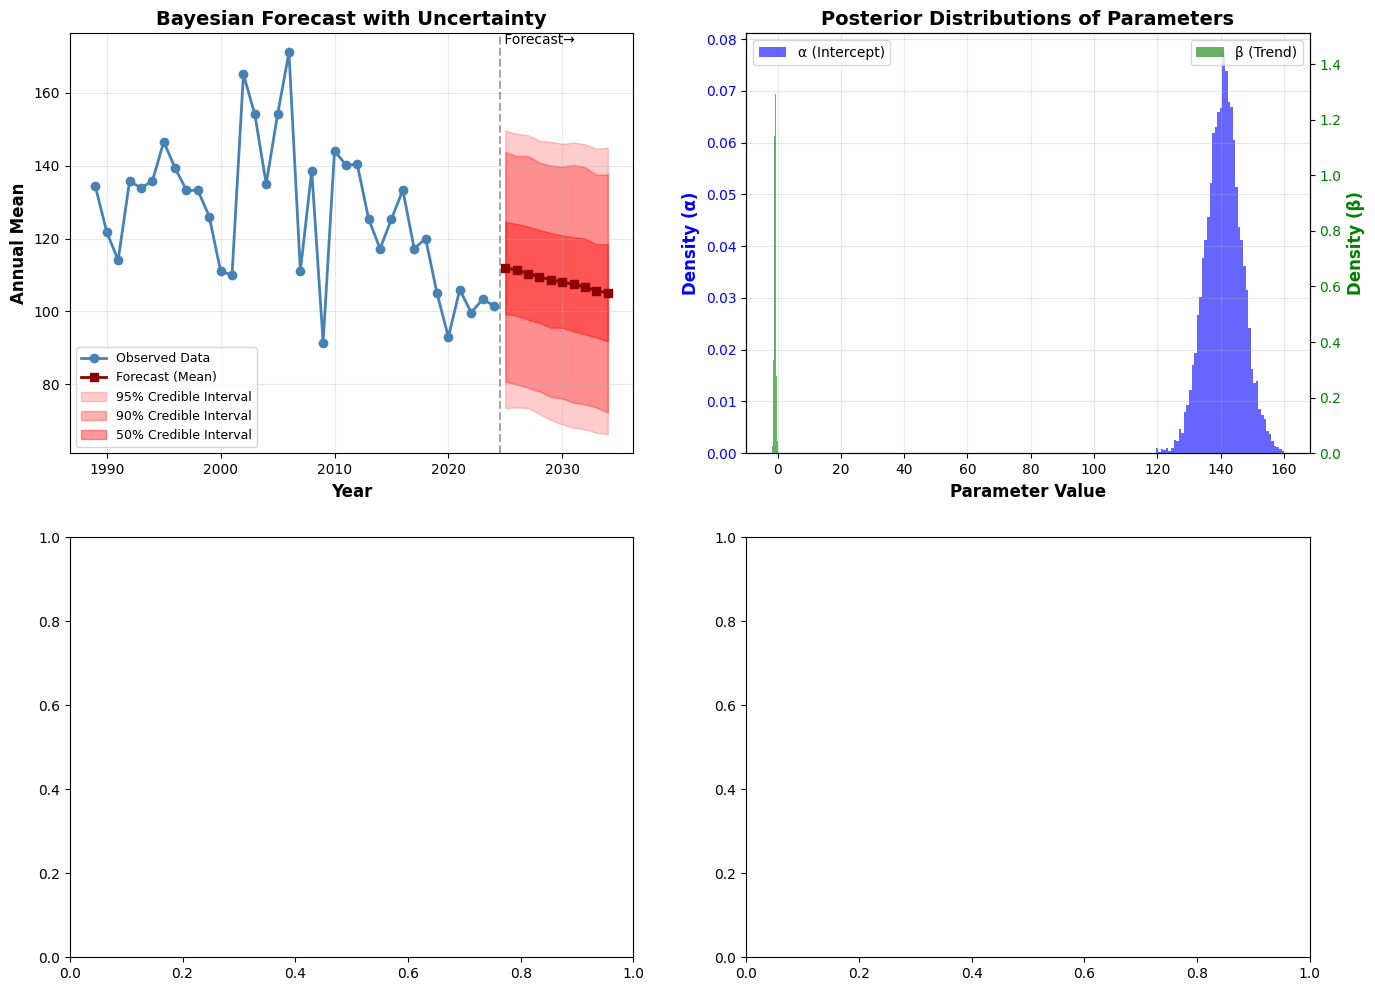

In [41]:
# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n" + "="*70)
print("Creating Visualizations")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Historical data with forecast
ax = axes[0, 0]
ax.plot(years, observations, 'o-', color='steelblue', linewidth=2, 
        markersize=6, label='Observed Data', zorder=3)
ax.plot(years_forecast, forecast_mean, 's-', color='darkred', linewidth=2,
        markersize=6, label='Forecast (Mean)', zorder=3)

# Uncertainty bands
ax.fill_between(years_forecast, ci_95[0], ci_95[1], 
                alpha=0.2, color='red', label='95% Credible Interval')
ax.fill_between(years_forecast, ci_90[0], ci_90[1], 
                alpha=0.3, color='red', label='90% Credible Interval')
ax.fill_between(years_forecast, ci_50[0], ci_50[1], 
                alpha=0.4, color='red', label='50% Credible Interval')

ax.axvline(x=2024.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(2024.5, ax.get_ylim()[1], ' Forecast→', fontsize=10, va='top')

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Annual Mean', fontsize=12, fontweight='bold')
ax.set_title('Bayesian Forecast with Uncertainty', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Posterior distributions of parameters
ax = axes[0, 1]
posterior_alpha = trace.posterior['alpha'].values.flatten()
posterior_beta = trace.posterior['beta'].values.flatten()

ax2 = ax.twinx()
ax.hist(posterior_alpha, bins=50, alpha=0.6, color='blue', density=True, label='α (Intercept)')
ax2.hist(posterior_beta, bins=50, alpha=0.6, color='green', density=True, label='β (Trend)')

ax.set_xlabel('Parameter Value', fontsize=12, fontweight='bold')
ax.set_ylabel('Density (α)', fontsize=12, fontweight='bold', color='blue')
ax2.set_ylabel('Density (β)', fontsize=12, fontweight='bold', color='green')
ax.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='green')
ax.set_title('Posterior Distributions of Parameters', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax2.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: Posterior predictive check
ax = axes[1, 0]
ppc_samples = ppc['y_obs'][:100]  # Plot 100 samples
for sample in ppc_samples:
    ax.plot(years, sample, color='lightblue', alpha=0.1, linewidth=0.5)
ax.plot(years, observations, 'o-', color='darkblue', linewidth=2, 
        markersize=6, label='Observed Data', zorder=3)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Annual Mean', fontsize=12, fontweight='bold')
ax.set_title('Posterior Predictive Check (Model Fit)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 4: Forecast fan chart
ax = axes[1, 1]
# Draw many forecast trajectories
n_trajectories = 200
sample_indices = np.random.choice(forecasts_flat.shape[1], n_trajectories, replace=False)
for idx in sample_indices:
    trajectory = forecasts_flat[:, idx]
    ax.plot(years_forecast, trajectory, color='red', alpha=0.05, linewidth=0.5)

ax.plot(years[-5:], observations[-5:], 'o-', color='steelblue', linewidth=2,
        markersize=6, label='Recent Data')
ax.plot(years_forecast, forecast_mean, 's-', color='darkred', linewidth=3,
        markersize=8, label='Forecast Mean', zorder=3)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Annual Mean', fontsize=12, fontweight='bold')
ax.set_title('Forecast Fan Chart (200 Trajectories)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bayesian_forecast.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as 'bayesian_forecast.png'")
plt.show()

In [31]:
years

array([1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999,
       2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2024])

In [32]:
observations

array([134.3, 121.7, 114.1, 135.7, 133.9, 135.7, 146.5, 139.3, 133.2,
       133.2, 126. , 111. , 110. , 165. , 154. , 135. , 154. , 127. ,
       171. , 111.1, 138.6,  91.5, 144.1, 140.1, 140.3, 125.3, 117.2,
       125.3, 133.3, 117.2, 120. , 105. ,  93. , 106. ,  99.7, 103.3,
       101.6])